# 05 — Análise Comparativa Final (SelfRegulationSCP1)

Carrega todos os `metrics.json` da run mais recente e compara raw / db4 / learned_wavelet.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
sys.path.insert(0, 'config')
from experiment_config import (
    SCP1_CONFIG, DATA_DIR, RESULTS_DIR, SEED,
    WAVELET_CONFIG, LEARNED_WAVELET_CONFIG, DL_TRAINING_CONFIG,
    ML_MODELS_CONFIG, ML_SEARCH_CONFIG, build_param_dist, N_JOBS_QUARTER,
)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
np.random.seed(SEED)
print('Dataset:', SCP1_CONFIG['dataset_name'], '| classes:', SCP1_CONFIG['n_classes'],
      '| seq_len:', SCP1_CONFIG['sequence_length'], '| canais:', SCP1_CONFIG['n_features'])

Dataset: SelfRegulationSCP1 | classes: 2 | seq_len: 896 | canais: 6


## 1. Carregar resultados da run mais recente

In [2]:
import json
runs = sorted([p for p in RESULTS_DIR.glob('????-??-??*') if (p/'queue_status.json').exists()], reverse=True)
assert runs, 'Nenhuma run — rode run_dl_queue.py primeiro.'
run_dir = runs[0]; print('Run:', run_dir.name)
rows = [json.loads(f.read_text()) for f in run_dir.rglob('metrics.json')]
df = pd.json_normalize(rows)
for col in ['test_accuracy','test_f1','test_auc_roc','val_accuracy']:
    df[col] = pd.to_numeric(df.get(col), errors='coerce')
print(len(df), 'configs avaliados')

Run: 2026-05-30_205240
1764 configs avaliados


## 2. Melhor por Model × Mode

In [3]:
best = df.groupby(['model_name','mode'])[['test_accuracy','test_f1','test_auc_roc']].max()
best.sort_values('test_accuracy', ascending=False).round(4)

test_accuracy  test_f1  test_auc_roc
model_name  mode                                                           
LSTM        learned_wavelet_no_warmup         0.9283   0.9278        0.9792
            learned_wavelet                   0.9215   0.9236        0.9698
MLP         learned_wavelet                   0.9215   0.9204        0.9527
CNN         learned_wavelet                   0.9147   0.9147        0.9565
MLP         learned_wavelet_no_warmup         0.9147   0.9141        0.9446
            raw                               0.9078   0.9091        0.9615
CNN         learned_wavelet_no_warmup         0.9044   0.9054        0.9542
MLP         db4                               0.9010   0.8938        0.9341
Transformer learned_wavelet                   0.8976   0.8986        0.9580
CNN_LSTM    learned_wavelet_no_warmup         0.8908   0.8933        0.9363
            learned_wavelet                   0.8840   0.8867        0.9334
Transformer learned_wavelet_no_warmup         0.8840   0.8867        0.9540
            raw                               0.8771   0.8831        0.9452
CNN         raw                               0.8771   0.8723        0.9410
Transformer db4                               0.8737   0.8683        0.9320
LSTM        db4                               0.8703   0.8701        0.9391
            raw                               0.8635   0.8675        0.9399
CNN         db4                               0.8601   0.8541        0.9335
CNN_LSTM    raw                               0.8396   0.8469        0.8791
            db4                               0.5802   0.6728        0.6157

## 3. Heatmap accuracy (Model × Mode)

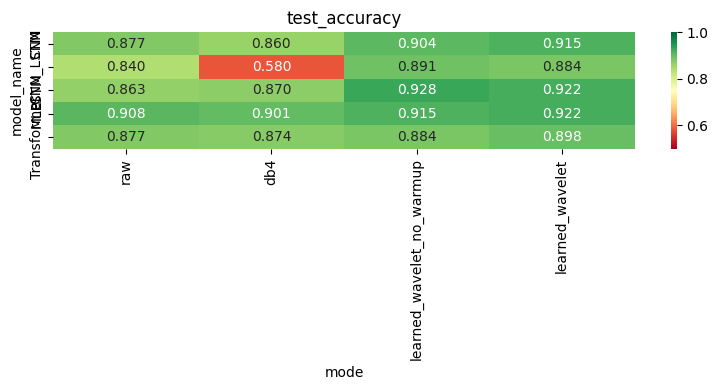

In [4]:
import seaborn as sns
pivot = df.groupby(['model_name','mode'])['test_accuracy'].max().unstack()
order_m = ['raw','db4','learned_wavelet_no_warmup','learned_wavelet']
pivot = pivot.reindex(columns=[c for c in order_m if c in pivot.columns])
plt.figure(figsize=(8,4)); sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0)
plt.title('test_accuracy'); plt.tight_layout(); plt.show()

## 4. Raw vs Fixed Wavelet vs Learned Wavelet

In [5]:
def bucket(m): return 'raw' if m=='raw' else ('fixed_wavelet' if m=='db4' else 'learned_wavelet')
df['bucket'] = df['mode'].map(bucket)
df.groupby('bucket')[['test_accuracy','test_f1','test_auc_roc']].agg(['mean','max']).round(4)

test_accuracy         test_f1         test_auc_roc        
                         mean     max    mean     max         mean     max
bucket                                                                    
fixed_wavelet          0.6960  0.9010  0.6913  0.8938       0.8060  0.9391
learned_wavelet        0.8030  0.9283  0.8118  0.9278       0.9060  0.9792
raw                    0.7799  0.9078  0.8063  0.9091       0.8819  0.9615

## 5. Ranking global (top 15)

In [6]:
cols = ['model_name','mode','config_idx','test_accuracy','test_f1','test_auc_roc']
df[cols].sort_values('test_accuracy', ascending=False).head(15).round(4)

,model_name,mode,config_idx,test_accuracy,test_f1,test_auc_roc
625,LSTM,learned_wavelet_no_warmup,143,0.9283,0.9278,0.9633
956,MLP,learned_wavelet,19,0.9215,0.9204,0.9527
1681,LSTM,learned_wavelet,106,0.9215,0.9236,0.9698
530,LSTM,learned_wavelet_no_warmup,109,0.9215,0.9226,0.9640
1478,LSTM,learned_wavelet,58,0.9181,0.9195,0.9633
1509,LSTM,learned_wavelet,98,0.9181,0.9184,0.9641
709,LSTM,learned_wavelet_no_warmup,68,0.9181,0.9172,0.9792
177,MLP,learned_wavelet_no_warmup,7,0.9147,0.9141,0.9396
145,CNN,learned_wavelet,43,0.9147,0.9147,0.9378
932,MLP,learned_wavelet,49,0.9147,0.9153,0.9467
